In [4]:
%load_ext autoreload
%autoreload 2
# import numpy as np
import matplotlib.pyplot as plt
import bayesnewton
import objax
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from model import ExactMarkovGP

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Single spatial coordinate

In [ ]:
# Make some training data
N_temporal_train = 10
N_spatial = 3
t = jnp.linspace(0., 2., N_temporal_train)
r = jnp.linspace(0., 1., N_spatial)
R = jnp.tile(r, (N_temporal_train, 1))
X = jnp.stack([jnp.tile(t[:, None], N_spatial).ravel(), R.ravel()], axis=1)
Y = (5 * X[:, 0] + jnp.sin(2*jnp.pi*X[:, 0]) + 10 * X[:, 1])
Y = Y.reshape(N_temporal_train, N_spatial)
noise_cov = jnp.tile(jnp.eye(N_spatial) * 0.001, (N_temporal_train, 1, 1))
t.shape, R.shape, Y.shape

((10,), (10, 3), (10, 3))

In [ ]:
# Define spatiotemporal kernel and measurement noise likelihood
lengthscale_spatial = 0.1
lengthscale_temporal = 0.5
variance_spatial = 2.0
variance_temporal = 6.0
variance_noise = 0.001 # Set very small to approximate zero noise data (doesn't work if set to zero)

likelihood = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern32(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern32(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
H = kernel.measurement_model()
gp = ExactMarkovGP(kernel=kernel, likelihood=likelihood, X=t, Y=Y, R=R)

Text(0.5, 1.0, 'Marginal likelhood: -134.191308873403')

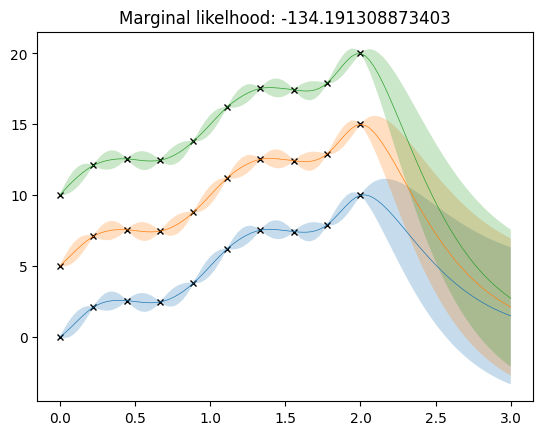

In [ ]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)
plt.plot(t, Y, color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean, lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelhood: {-gp.filter_energy()}")

In [ ]:
lr_adam = 0.05
epochs = 100

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: 54.7133
epoch  2: loss: 54.7043
epoch  3: loss: 54.7045
epoch  4: loss: 54.6955
epoch  5: loss: 54.6958
epoch  6: loss: 54.6869
epoch  7: loss: 54.6872
epoch  8: loss: 54.6783
epoch  9: loss: 54.6786
epoch 10: loss: 54.6698
epoch 11: loss: 54.6702
epoch 12: loss: 54.6614
epoch 13: loss: 54.6619
epoch 14: loss: 54.6531
epoch 15: loss: 54.6536
epoch 16: loss: 54.6449
epoch 17: loss: 54.6454
epoch 18: loss: 54.6367
epoch 19: loss: 54.6373
epoch 20: loss: 54.6287
epoch 21: loss: 54.6293
epoch 22: loss: 54.6207
epoch 23: loss: 54.6213
epoch 24: loss: 54.6128
epoch 25: loss: 54.6135
epoch 26: loss: 54.6050
epoch 27: loss: 54.6057
epoch 28: loss: 54.5972
epoch 29: loss: 54.5980
epoch 30: loss: 54.5895
epoch 31: loss: 54.5904
epoch 32: loss: 54.5820
epoch 33: loss: 54.5828
epoch 34: loss: 54.5744
epoch 35: loss: 54.5753
epoch 36: loss: 54.5670
epoch 37: loss: 54.5679
epoch 38: loss: 54.5596
epoch 39: loss: 54.5606
epoch 40: loss: 54.5523
epoch 41: loss: 54.5534
epoch 42: loss: 

In [630]:
kernel.spatial_kernel.lengthscale, kernel.temporal_kernel.lengthscale, kernel.spatial_kernel.variance, kernel.temporal_kernel.variance

(Array(0.1, dtype=float64, weak_type=True),
 Array(2.69200415, dtype=float64, weak_type=True),
 Array(2., dtype=float64, weak_type=True),
 Array(25.98955848, dtype=float64, weak_type=True))

In [ ]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)

Text(0.5, 1.0, 'Marginal likelhood: -54.36483156582663')

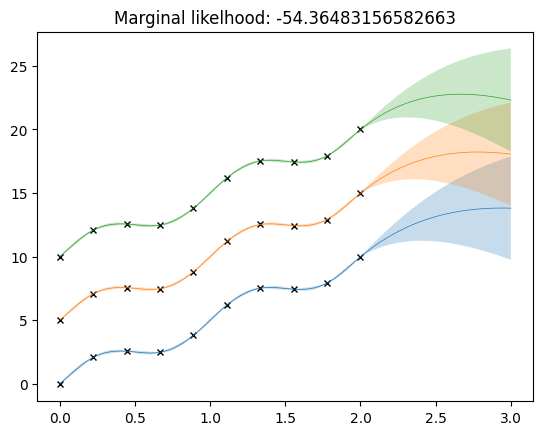

In [ ]:
plt.plot(t, Y, color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean, lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelhood: {-gp.filter_energy()}")

# Multiple spatial coordinates

In [11]:
# Make some training data
N_temporal_train = 100
N_x, N_y = 4, 6
N_spatial = N_x * N_y
N_dim = 2
t = jnp.linspace(0., 2., N_temporal_train)
x = jnp.linspace(0., 1., N_x)
y = jnp.linspace(0., 1., N_y)
x, y = jnp.meshgrid(x, y)
r = jnp.stack([x.ravel(), x.ravel()], axis=1)
R = jnp.tile(r, (N_temporal_train, 1, 1))
X = jnp.concatenate([jnp.tile(t[:, None], N_spatial).reshape(-1, 1), R.reshape(-1, N_dim)], axis=1) # Need to compute Y
Y = (5 * X[:, 0] + jnp.sin(2*jnp.pi*X[:, 0]) + 3 * X[:, 1]) + 10 * X[:, 2]
Y = Y.reshape(N_temporal_train, N_spatial)
t.shape, R.shape, Y.shape

((100,), (100, 24, 2), (100, 24))

In [12]:
# Define spatiotemporal kernel and measurement noise, and initialise hyperparameters
lengthscale_spatial = 0.1
lengthscale_temporal = 1.4
variance_spatial = 2.0
variance_temporal = 120
variance_noise = 0.001

lik = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern52(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern52(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
gp = ExactMarkovGP(kernel=kernel, likelihood=lik, X=t, Y=Y, R=R)

In [13]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)

Text(0.5, 1.0, 'Marginal likelihood: 4554.268278800158')

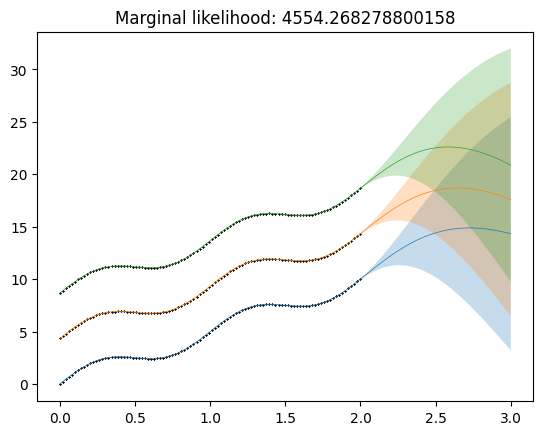

In [14]:
plt.plot(t, Y[:, :3], color='black', marker='x', linestyle='none', ms=1)
plt.plot(t_test, test_mean[:, :3], lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelihood: {-gp.filter_energy()}")

In [15]:
# Optimise the hyperparameters
lr_adam = 0.025
epochs = 100

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: -4554.2683
epoch  2: loss: -4567.4488
epoch  3: loss: -4579.7908
epoch  4: loss: -4591.2552
epoch  5: loss: -4601.8011
epoch  6: loss: -4611.3930
epoch  7: loss: -4619.9898
epoch  8: loss: -4628.4372
epoch  9: loss: -4636.6909
epoch 10: loss: -4644.8709
epoch 11: loss: -4652.7878
epoch 12: loss: -4660.7079
epoch 13: loss: -4668.2943
epoch 14: loss: -4675.9621
epoch 15: loss: -4683.2246
epoch 16: loss: -4690.6477
epoch 17: loss: -4697.5933
epoch 18: loss: -4704.7792
epoch 19: loss: -4711.4149
epoch 20: loss: -4718.3713
epoch 21: loss: -4724.7042
epoch 22: loss: -4731.4385
epoch 23: loss: -4737.4761
epoch 24: loss: -4743.9958
epoch 25: loss: -4749.7455
epoch 26: loss: -4756.0579
epoch 27: loss: -4761.5273
epoch 28: loss: -4767.6397
epoch 29: loss: -4772.8364
epoch 30: loss: -4778.7560
epoch 31: loss: -4783.6876
epoch 32: loss: -4789.4213
epoch 33: loss: -4794.0957
epoch 34: loss: -4799.6504
epoch 35: loss: -4804.0756
epoch 36: loss: -4809.4576
epoch 37: loss: -4813.7361
e

In [16]:
print(lengthscale_spatial, lengthscale_temporal, variance_spatial, variance_temporal)
gp.kernel.spatial_kernel.lengthscale, gp.kernel.temporal_kernel.lengthscale, gp.kernel.spatial_kernel.variance, gp.kernel.temporal_kernel.variance

0.1 1.4 2.0 120


(Array(0.1, dtype=float64, weak_type=True),
 Array(1.47624495, dtype=float64, weak_type=True),
 Array(2., dtype=float64, weak_type=True),
 Array(122.29975741, dtype=float64, weak_type=True))

Text(0.5, 1.0, 'Marginal likelihood: 4973.852240774294')

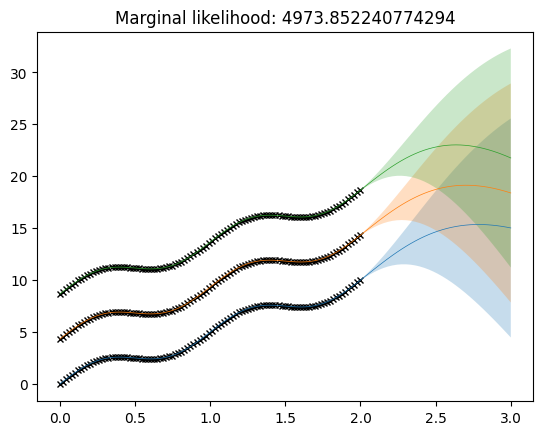

In [17]:
# Extrapolate in time for three spatial locations
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)
plt.plot(t, Y[:, :3], color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean[:, :3], lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelihood: {-gp.filter_energy()}")